# LLM Segment Distinctness Analysis

This notebook measures if LLM-generated segments are **distinct from one another** within a single run.

## Goal
Prove that Feature-Driven Pre-Analysis provides clear, non-redundant signals that prevent the LLM from generating overlapping or repetitive narratives.

## Methodology
1. Convert "Title + Description" for each segment into a high-dimensional vector using an embedding model
2. Calculate **distinctness metrics** using pairwise comparisons of embeddings:
   - **Mean Pairwise Similarity** (Primary) - Lower = more distinct
   - **Minimum Pairwise Distance** (Supporting) - Higher = no redundancy  
   - **Mean Centroid Distance** (Supporting) - Higher = more diverse coverage

## Datasets Analyzed

### Telco Customer Churn Dataset
- **Baseline**: Level 1 from Telco_baseline.csv
- **Auto-k L1 (Micro)**: Level 1 from Telco_star_mode.csv
- **Auto-k L2 (Macro)**: Level 2 from Telco_star_mode.csv

### Retail Dataset
- **Baseline**: Level 1 from Retail_baseline.csv
- **Auto-k L1 (Micro)**: Level 1 from Retail_star_mode.csv
- **Auto-k L2 (Macro)**: Level 2 from Retail_star_mode.csv

In [51]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 1: Load and Prepare Data

In [52]:
# Load the CSV files for both datasets
print("="*70)
print("LOADING TELCO DATASET")
print("="*70)
telco_baseline_df = pd.read_csv('Telco_baseline.csv')
telco_star_mode_df = pd.read_csv('Telco_star_mode.csv')

print("Telco Baseline Shape:", telco_baseline_df.shape)
print("Telco Star Mode Shape:", telco_star_mode_df.shape)
print("Telco Baseline levels:", telco_baseline_df['level'].unique())
print("Telco Star Mode levels:", telco_star_mode_df['level'].unique())

print("\n" + "="*70)
print("LOADING RETAIL DATASET")
print("="*70)

retail_baseline_df = pd.read_csv('Retail_baseline.csv')
retail_star_mode_df = pd.read_csv('Retail_star_mode.csv')

print("Retail Baseline Shape:", retail_baseline_df.shape)
print("Retail Star Mode Shape:", retail_star_mode_df.shape)
print("Retail Baseline levels:", retail_baseline_df['level'].unique())
print("Retail Star Mode levels:", retail_star_mode_df['level'].unique())

print("\n✓ All datasets loaded successfully!")


LOADING TELCO DATASET
Telco Baseline Shape: (4, 4)
Telco Star Mode Shape: (69, 4)
Telco Baseline levels: [1]
Telco Star Mode levels: [1 2]

LOADING RETAIL DATASET
Retail Baseline Shape: (13, 4)
Retail Star Mode Shape: (33, 4)
Retail Baseline levels: [1]
Retail Star Mode levels: [1 2]

✓ All datasets loaded successfully!


In [53]:
# Preview both datasets
print("="*70)
print("TELCO DATASET PREVIEW")
print("="*70)
print("\n=== Telco Baseline Sample ===")
print(telco_baseline_df.head(2))
print("\n=== Telco Star Mode Level 1 Sample ===")
print(telco_star_mode_df[telco_star_mode_df['level'] == 1].head(2))

print("\n" + "="*70)
print("RETAIL DATASET PREVIEW")
print("="*70)
print("\n=== Retail Baseline Sample ===")
print(retail_baseline_df.head(2))
print("\n=== Retail Star Mode Level 1 Sample ===")
print(retail_star_mode_df[retail_star_mode_df['level'] == 1].head(2))

TELCO DATASET PREVIEW

=== Telco Baseline Sample ===
   level  cluster_id                                       title  \
0      1        7043  Demographic Features: Gender and Seniority   
1      1        7044  Demographics: Seniority and Partner Status   

                                         description  
0  This cluster represents individuals' gender an...  
1  This cluster contains demographic information ...  

=== Telco Star Mode Level 1 Sample ===
   level  cluster_id                                             title  \
0      1        7043                    Two Year Contract, No Internet   
1      1        7044  Two Year Contract, No Internet, Auto Credit Card   

                                         description  
0  Customers with two-year contracts are signific...  
1  This cluster comprises customers on two-year c...  

RETAIL DATASET PREVIEW

=== Retail Baseline Sample ===
   level  cluster_id                            title  \
0      1        4339     High Moneta

## Step 2: Extract Variants for Both Datasets

In [54]:
# Extract the three variants for Telco
print("="*70)
print("TELCO VARIANTS")
print("="*70)
telco_baseline_l1 = telco_baseline_df[telco_baseline_df['level'] == 1].copy()
telco_star_l1 = telco_star_mode_df[telco_star_mode_df['level'] == 1].copy()
telco_star_l2 = telco_star_mode_df[telco_star_mode_df['level'] == 2].copy()

print(f"Telco Baseline L1: {len(telco_baseline_l1)} segments")
print(f"Telco Auto-k L1 (Micro): {len(telco_star_l1)} segments")
print(f"Telco Auto-k L2 (Macro): {len(telco_star_l2)} segments")

# Extract the three variants for Retail
print("\n" + "="*70)
print("RETAIL VARIANTS")
print("="*70)
retail_baseline_l1 = retail_baseline_df[retail_baseline_df['level'] == 1].copy()
retail_star_l1 = retail_star_mode_df[retail_star_mode_df['level'] == 1].copy()
retail_star_l2 = retail_star_mode_df[retail_star_mode_df['level'] == 2].copy()

print(f"Retail Baseline L1: {len(retail_baseline_l1)} segments")
print(f"Retail Auto-k L1 (Micro): {len(retail_star_l1)} segments")
print(f"Retail Auto-k L2 (Macro): {len(retail_star_l2)} segments")

TELCO VARIANTS
Telco Baseline L1: 4 segments
Telco Auto-k L1 (Micro): 66 segments
Telco Auto-k L2 (Macro): 3 segments

RETAIL VARIANTS
Retail Baseline L1: 13 segments
Retail Auto-k L1 (Micro): 31 segments
Retail Auto-k L2 (Macro): 2 segments


In [55]:
# Combine Title + Description for all variants
def create_text_representation(df):
    """Combine title and description into a single text representation"""
    df = df.copy()
    df['text'] = df['title'] + ". " + df['description']
    return df

print("Creating text representations...")

# Telco
telco_baseline_l1 = create_text_representation(telco_baseline_l1)
telco_star_l1 = create_text_representation(telco_star_l1)
telco_star_l2 = create_text_representation(telco_star_l2)

# Retail
retail_baseline_l1 = create_text_representation(retail_baseline_l1)
retail_star_l1 = create_text_representation(retail_star_l1)
retail_star_l2 = create_text_representation(retail_star_l2)

print("\u2713 Text representations created for both datasets")
print("\nSample from Telco Baseline:")
print(telco_baseline_l1['text'].iloc[0][:150] + "...")
print("\nSample from Retail Baseline:")
print(retail_baseline_l1['text'].iloc[0][:150] + "...")

Creating text representations...
✓ Text representations created for both datasets

Sample from Telco Baseline:
Demographic Features: Gender and Seniority. This cluster represents individuals' gender and senior citizen status. The data indicates a near-equal spl...

Sample from Retail Baseline:
High Monetary, Low Frequency. This cluster represents items with high monetary value and low frequency of purchase. These items are infrequent but val...


## Step 3: Load Embedding Model and Generate Embeddings

In [56]:
# Load a pre-trained sentence embedding model
print("Loading embedding model...")
model = SentenceTransformer('all-MiniLM-L6-v2')  # Fast and efficient model
print("Model loaded successfully!")
print(f"Embedding dimension: {model.get_sentence_embedding_dimension()}")

Loading embedding model...


Model loaded successfully!
Embedding dimension: 384


In [57]:
# Generate embeddings for all variants (Telco + Retail)
print("Generating embeddings...")

# === TELCO DATASET ===
print("\n" + "="*60)
print("TELCO DATASET")
print("="*60)

# Telco Baseline
print("Processing Telco Baseline L1...")
telco_baseline_embeddings = model.encode(telco_baseline_l1['text'].tolist(), show_progress_bar=True)
telco_baseline_labels = telco_baseline_l1['cluster_id'].values

# Telco Auto-k L1 (Micro)
print("\nProcessing Telco Auto-k L1 (Micro)...")
telco_star_l1_embeddings = model.encode(telco_star_l1['text'].tolist(), show_progress_bar=True)
telco_star_l1_labels = telco_star_l1['cluster_id'].values

# Telco Auto-k L2 (Macro)
print("\nProcessing Telco Auto-k L2 (Macro)...")
telco_star_l2_embeddings = model.encode(telco_star_l2['text'].tolist(), show_progress_bar=True)
telco_star_l2_labels = telco_star_l2['cluster_id'].values

print(f"\n✓ Telco Baseline embeddings shape: {telco_baseline_embeddings.shape}")
print(f"✓ Telco Auto-k L1 embeddings shape: {telco_star_l1_embeddings.shape}")
print(f"✓ Telco Auto-k L2 embeddings shape: {telco_star_l2_embeddings.shape}")

# === RETAIL DATASET ===
print("\n" + "="*60)
print("RETAIL DATASET")
print("="*60)

# Retail Baseline
print("Processing Retail Baseline L1...")
retail_baseline_embeddings = model.encode(retail_baseline_l1['text'].tolist(), show_progress_bar=True)
retail_baseline_labels = retail_baseline_l1['cluster_id'].values

# Retail Auto-k L1 (Micro)
print("\nProcessing Retail Auto-k L1 (Micro)...")
retail_star_l1_embeddings = model.encode(retail_star_l1['text'].tolist(), show_progress_bar=True)
retail_star_l1_labels = retail_star_l1['cluster_id'].values

# Retail Auto-k L2 (Macro)
print("\nProcessing Retail Auto-k L2 (Macro)...")
retail_star_l2_embeddings = model.encode(retail_star_l2['text'].tolist(), show_progress_bar=True)
retail_star_l2_labels = retail_star_l2['cluster_id'].values

print(f"\n✓ Retail Baseline embeddings shape: {retail_baseline_embeddings.shape}")
print(f"✓ Retail Auto-k L1 embeddings shape: {retail_star_l1_embeddings.shape}")
print(f"✓ Retail Auto-k L2 embeddings shape: {retail_star_l2_embeddings.shape}")

print("\n" + "="*60)
print(f"TOTAL: 6 variants processed ({telco_baseline_embeddings.shape[0] + telco_star_l1_embeddings.shape[0] + telco_star_l2_embeddings.shape[0] + retail_baseline_embeddings.shape[0] + retail_star_l1_embeddings.shape[0] + retail_star_l2_embeddings.shape[0]} segments)")
print("="*60)

Generating embeddings...

TELCO DATASET
Processing Telco Baseline L1...


Batches: 100%|██████████| 1/1 [00:00<00:00,  3.63it/s]



Processing Telco Auto-k L1 (Micro)...


Batches: 100%|██████████| 3/3 [00:01<00:00,  2.91it/s]



Processing Telco Auto-k L2 (Macro)...


...


Processing Retail Auto-k L1 (Micro)...


Batches: 100%|██████████| 1/1 [00:00<00:00,  2.06it/s]



Processing Retail Auto-k L2 (Macro)...


Batches: 100%|██████████| 1/1 [00:00<00:00, 27.26it/s]


✓ Retail Baseline embeddings shape: (13, 384)
✓ Retail Auto-k L1 embeddings shape: (31, 384)
✓ Retail Auto-k L2 embeddings shape: (2, 384)

TOTAL: 6 variants processed (119 segments)


## Step 4: Calculate Distinctness Metrics

Three complementary metrics measure semantic distinctness:

1. **Mean Pairwise Similarity** (PRIMARY) - Average similarity between all pairs (lower = more distinct)
2. **Minimum Pairwise Distance** (SUPPORTING) - Distance between the two most similar segments (higher = more distinct)
3. **Mean Centroid Distance** (SUPPORTING) - How spread out the segments are (higher = more distinct)

In [58]:
# Calculate Distinctness Metrics

def calculate_distinctness_metrics(embeddings, name):
    """Calculate distinctness metrics that work with any dataset size"""
    n_samples = len(embeddings)
    
    if n_samples < 2:
        print(f"⚠ {name}: Only 1 segment, cannot calculate distinctness")
        return None, None
    
    # Calculate pairwise cosine similarities
    similarities = cosine_similarity(embeddings)
    
    # Get upper triangle (excluding diagonal) for unique pairs
    mask = np.triu(np.ones_like(similarities, dtype=bool), k=1)
    pairwise_sims = similarities[mask]
    
    # Calculate distances (1 - similarity for cosine)
    pairwise_dists = 1 - pairwise_sims
    
    # Calculate centroid and distances from centroid
    centroid = embeddings.mean(axis=0)
    centroid_distances = np.sqrt(np.sum((embeddings - centroid) ** 2, axis=1))
    
    metrics = {
        'n_segments': n_samples,
        'mean_pairwise_similarity': pairwise_sims.mean(),
        'min_pairwise_similarity': pairwise_sims.min(),
        'max_pairwise_similarity': pairwise_sims.max(),
        'mean_pairwise_distance': pairwise_dists.mean(),
        'min_pairwise_distance': pairwise_dists.min(),
        'max_pairwise_distance': pairwise_dists.max(),
        'mean_centroid_distance': centroid_distances.mean(),
        'std_centroid_distance': centroid_distances.std()
    }
    
    print(f"\n{'='*70}")
    print(f"{name} - Distinctness Metrics")
    print(f"{'='*70}")
    print(f"Number of segments: {n_samples}")
    print(f"Number of unique pairs: {len(pairwise_sims)}")
    print(f"\nPairwise Similarity (PRIMARY - lower = more distinct):")
    print(f"  - Mean: {metrics['mean_pairwise_similarity']:.4f}")
    print(f"  - Min:  {metrics['min_pairwise_similarity']:.4f} (most different pair)")
    print(f"  - Max:  {metrics['max_pairwise_similarity']:.4f} (most similar pair)")
    print(f"\nPairwise Distance (SUPPORTING - higher = more distinct):")
    print(f"  - Mean: {metrics['mean_pairwise_distance']:.4f}")
    print(f"  - Min:  {metrics['min_pairwise_distance']:.4f} (closest pair)")
    print(f"  - Max:  {metrics['max_pairwise_distance']:.4f} (furthest pair)")
    print(f"\nSpread/Diversity (SUPPORTING - higher = more diverse):")
    print(f"  - Mean Centroid Distance: {metrics['mean_centroid_distance']:.4f}")
    print(f"  - Std Centroid Distance:  {metrics['std_centroid_distance']:.4f}")
    
    return metrics, similarities

# Calculate for all variants (Telco + Retail)

print("\n" + "="*70)
print("TELCO DATASET - DISTINCTNESS METRICS")
print("="*70)

telco_baseline_metrics, telco_baseline_sim_matrix = calculate_distinctness_metrics(
    telco_baseline_embeddings, "Telco Baseline (Level 1)"
)

telco_star_l1_metrics, telco_star_l1_sim_matrix = calculate_distinctness_metrics(
    telco_star_l1_embeddings, "Telco Auto-k L1 (Micro)"
)

telco_star_l2_metrics, telco_star_l2_sim_matrix = calculate_distinctness_metrics(
    telco_star_l2_embeddings, "Telco Auto-k L2 (Macro)"
)

print("\n" + "="*70)
print("RETAIL DATASET - DISTINCTNESS METRICS")
print("="*70)

retail_baseline_metrics, retail_baseline_sim_matrix = calculate_distinctness_metrics(
    retail_baseline_embeddings, "Retail Baseline (Level 1)"
)

retail_star_l1_metrics, retail_star_l1_sim_matrix = calculate_distinctness_metrics(
    retail_star_l1_embeddings, "Retail Auto-k L1 (Micro)"
)

retail_star_l2_metrics, retail_star_l2_sim_matrix = calculate_distinctness_metrics(
    retail_star_l2_embeddings, "Retail Auto-k L2 (Macro)"
)


TELCO DATASET - DISTINCTNESS METRICS

Telco Baseline (Level 1) - Distinctness Metrics
Number of segments: 4
Number of unique pairs: 6

Pairwise Similarity (PRIMARY - lower = more distinct):
  - Mean: 0.8307
  - Min:  0.7561 (most different pair)
  - Max:  0.9193 (most similar pair)

Pairwise Distance (SUPPORTING - higher = more distinct):
  - Mean: 0.1693
  - Min:  0.0807 (closest pair)
  - Max:  0.2439 (furthest pair)

Spread/Diversity (SUPPORTING - higher = more diverse):
  - Mean Centroid Distance: 0.3509
  - Std Centroid Distance:  0.0623

Telco Auto-k L1 (Micro) - Distinctness Metrics
Number of segments: 66
Number of unique pairs: 2145

Pairwise Similarity (PRIMARY - lower = more distinct):
  - Mean: 0.6186
  - Min:  0.1338 (most different pair)
  - Max:  0.9860 (most similar pair)

Pairwise Distance (SUPPORTING - higher = more distinct):
  - Mean: 0.3814
  - Min:  0.0140 (closest pair)
  - Max:  0.8662 (furthest pair)

Spread/Diversity (SUPPORTING - higher = more diverse):
  - M

## Step 4.5: Identify Duplicate/Similar Segments (Diagnostics)

When the minimum pairwise distance is 0 or very close to 0, it indicates duplicate or near-duplicate text. Let's identify which segments are duplicates.

In [59]:
# Function to find duplicate or near-duplicate segments
def find_duplicates(df, embeddings, sim_matrix, name, threshold=0.999):
    """Find segments with very high similarity (potential duplicates)"""
    print(f"\n{'='*70}")
    print(f"{name} - Duplicate Detection")
    print(f"{'='*70}")
    
    # Find pairs with similarity >= threshold
    duplicates = []
    n = len(sim_matrix)
    
    for i in range(n):
        for j in range(i+1, n):
            if sim_matrix[i, j] >= threshold:
                duplicates.append({
                    'idx1': i,
                    'idx2': j,
                    'similarity': sim_matrix[i, j],
                    'cluster1': df.iloc[i]['cluster_id'],
                    'cluster2': df.iloc[j]['cluster_id'],
                    'title1': df.iloc[i]['title'],
                    'title2': df.iloc[j]['title']
                })
    
    if duplicates:
        print(f"\n⚠ Found {len(duplicates)} duplicate/near-duplicate pairs (similarity ≥ {threshold}):\n")
        for dup in duplicates:
            print(f"Similarity: {dup['similarity']:.6f}")
            print(f"  Cluster {dup['cluster1']}: \"{dup['title1']}\"")
            print(f"  Cluster {dup['cluster2']}: \"{dup['title2']}\"")
            print(f"  Text 1: {df.iloc[dup['idx1']]['text'][:100]}...")
            print(f"  Text 2: {df.iloc[dup['idx2']]['text'][:100]}...")
            print()
    else:
        print(f"✓ No duplicates found (all pairs have similarity < {threshold})")
    
    return duplicates

# Check for duplicates in all variants
print("\n" + "="*70)
print("DUPLICATE DETECTION ANALYSIS")
print("="*70)

telco_baseline_dupes = find_duplicates(telco_baseline_l1, telco_baseline_embeddings, 
                                       telco_baseline_sim_matrix, "Telco Baseline")
telco_star_l1_dupes = find_duplicates(telco_star_l1, telco_star_l1_embeddings, 
                                      telco_star_l1_sim_matrix, "Telco Auto-k L1")
telco_star_l2_dupes = find_duplicates(telco_star_l2, telco_star_l2_embeddings, 
                                      telco_star_l2_sim_matrix, "Telco Auto-k L2")

retail_baseline_dupes = find_duplicates(retail_baseline_l1, retail_baseline_embeddings, 
                                        retail_baseline_sim_matrix, "Retail Baseline")
retail_star_l1_dupes = find_duplicates(retail_star_l1, retail_star_l1_embeddings, 
                                       retail_star_l1_sim_matrix, "Retail Auto-k L1")
retail_star_l2_dupes = find_duplicates(retail_star_l2, retail_star_l2_embeddings, 
                                       retail_star_l2_sim_matrix, "Retail Auto-k L2")

print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"Telco Baseline: {len(telco_baseline_dupes)} duplicate pairs")
print(f"Telco Auto-k L1: {len(telco_star_l1_dupes)} duplicate pairs")
print(f"Telco Auto-k L2: {len(telco_star_l2_dupes)} duplicate pairs")
print(f"Retail Baseline: {len(retail_baseline_dupes)} duplicate pairs")
print(f"Retail Auto-k L1: {len(retail_star_l1_dupes)} duplicate pairs")
print(f"Retail Auto-k L2: {len(retail_star_l2_dupes)} duplicate pairs")


DUPLICATE DETECTION ANALYSIS

Telco Baseline - Duplicate Detection
✓ No duplicates found (all pairs have similarity < 0.999)

Telco Auto-k L1 - Duplicate Detection
✓ No duplicates found (all pairs have similarity < 0.999)

Telco Auto-k L2 - Duplicate Detection
✓ No duplicates found (all pairs have similarity < 0.999)

Retail Baseline - Duplicate Detection

⚠ Found 2 duplicate/near-duplicate pairs (similarity ≥ 0.999):

Similarity: 1.000000
  Cluster 4342: "Average Recency, Low Frequency"
  Cluster 4346: "Average Recency, Low Frequency"
  Text 1: Average Recency, Low Frequency. This cluster represents items with average recency and low frequency...
  Text 2: Average Recency, Low Frequency. This cluster represents items with average recency and low frequency...

Similarity: 1.000000
  Cluster 4343: "Mixed Recency, Moderate Frequency"
  Cluster 4348: "Mixed Recency, Moderate Frequency"
  Text 1: Mixed Recency, Moderate Frequency. This cluster features items with mixed recency and moderat

In [60]:
# Create comparison tables for both datasets
print("\n" + "="*90)
print("LLM SEGMENT DISTINCTNESS COMPARISON - TELCO DATASET")
print("="*90)

telco_comparison_data = {
    'Variant': ['Baseline', 'Auto-k L1 (Micro)', 'Auto-k L2 (Macro)'],
    'Segments': [
        telco_baseline_metrics['n_segments'] if telco_baseline_metrics else 0,
        telco_star_l1_metrics['n_segments'] if telco_star_l1_metrics else 0,
        telco_star_l2_metrics['n_segments'] if telco_star_l2_metrics else 0
    ],
    'Mean Similarity\n(Lower=Better)': [
        f"{telco_baseline_metrics['mean_pairwise_similarity']:.4f}" if telco_baseline_metrics else 'N/A',
        f"{telco_star_l1_metrics['mean_pairwise_similarity']:.4f}" if telco_star_l1_metrics else 'N/A',
        f"{telco_star_l2_metrics['mean_pairwise_similarity']:.4f}" if telco_star_l2_metrics else 'N/A'
    ],
    'Min Pairwise Distance\n(Higher=Better)': [
        f"{telco_baseline_metrics['min_pairwise_distance']:.4f}" if telco_baseline_metrics else 'N/A',
        f"{telco_star_l1_metrics['min_pairwise_distance']:.4f}" if telco_star_l1_metrics else 'N/A',
        f"{telco_star_l2_metrics['min_pairwise_distance']:.4f}" if telco_star_l2_metrics else 'N/A'
    ],
    'Mean Centroid Distance\n(Higher=Better)': [
        f"{telco_baseline_metrics['mean_centroid_distance']:.4f}" if telco_baseline_metrics else 'N/A',
        f"{telco_star_l1_metrics['mean_centroid_distance']:.4f}" if telco_star_l1_metrics else 'N/A',
        f"{telco_star_l2_metrics['mean_centroid_distance']:.4f}" if telco_star_l2_metrics else 'N/A'
    ]
}

telco_comparison_df = pd.DataFrame(telco_comparison_data)
print(telco_comparison_df.to_string(index=False))

print("\n" + "="*90)
print("LLM SEGMENT DISTINCTNESS COMPARISON - RETAIL DATASET")
print("="*90)

retail_comparison_data = {
    'Variant': ['Baseline', 'Auto-k L1 (Micro)', 'Auto-k L2 (Macro)'],
    'Segments': [
        retail_baseline_metrics['n_segments'] if retail_baseline_metrics else 0,
        retail_star_l1_metrics['n_segments'] if retail_star_l1_metrics else 0,
        retail_star_l2_metrics['n_segments'] if retail_star_l2_metrics else 0
    ],
    'Mean Similarity\n(Lower=Better)': [
        f"{retail_baseline_metrics['mean_pairwise_similarity']:.4f}" if retail_baseline_metrics else 'N/A',
        f"{retail_star_l1_metrics['mean_pairwise_similarity']:.4f}" if retail_star_l1_metrics else 'N/A',
        f"{retail_star_l2_metrics['mean_pairwise_similarity']:.4f}" if retail_star_l2_metrics else 'N/A'
    ],
    'Min Pairwise Distance\n(Higher=Better)': [
        f"{retail_baseline_metrics['min_pairwise_distance']:.4f}" if retail_baseline_metrics else 'N/A',
        f"{retail_star_l1_metrics['min_pairwise_distance']:.4f}" if retail_star_l1_metrics else 'N/A',
        f"{retail_star_l2_metrics['min_pairwise_distance']:.4f}" if retail_star_l2_metrics else 'N/A'
    ],
    'Mean Centroid Distance\n(Higher=Better)': [
        f"{retail_baseline_metrics['mean_centroid_distance']:.4f}" if retail_baseline_metrics else 'N/A',
        f"{retail_star_l1_metrics['mean_centroid_distance']:.4f}" if retail_star_l1_metrics else 'N/A',
        f"{retail_star_l2_metrics['mean_centroid_distance']:.4f}" if retail_star_l2_metrics else 'N/A'
    ]
}

retail_comparison_df = pd.DataFrame(retail_comparison_data)
print(retail_comparison_df.to_string(index=False))

print("\n" + "="*90)
print("INTERPRETATION GUIDE")
print("="*90)
print("  - Mean Similarity (Lower=Better): Segments are more semantically different")
print("  - Min Pairwise Distance (Higher=Better): Even the closest pair is well-separated")
print("  - Mean Centroid Distance (Higher=Better): More spread out / diverse coverage")
print("\nCompare across datasets to see if Feature-Driven Pre-Analysis produces")
print("consistently distinct segments across different domains (Telco vs Retail).")


LLM SEGMENT DISTINCTNESS COMPARISON - TELCO DATASET
          Variant  Segments Mean Similarity\n(Lower=Better) Min Pairwise Distance\n(Higher=Better) Mean Centroid Distance\n(Higher=Better)
         Baseline         4                          0.8307                                 0.0807                                  0.3509
Auto-k L1 (Micro)        66                          0.6186                                 0.0140                                  0.5934
Auto-k L2 (Macro)         3                          0.6912                                 0.2266                                  0.4469

LLM SEGMENT DISTINCTNESS COMPARISON - RETAIL DATASET
          Variant  Segments Mean Similarity\n(Lower=Better) Min Pairwise Distance\n(Higher=Better) Mean Centroid Distance\n(Higher=Better)
         Baseline        13                          0.8428                                 0.0000                                  0.3673
Auto-k L1 (Micro)        31                          0.5881

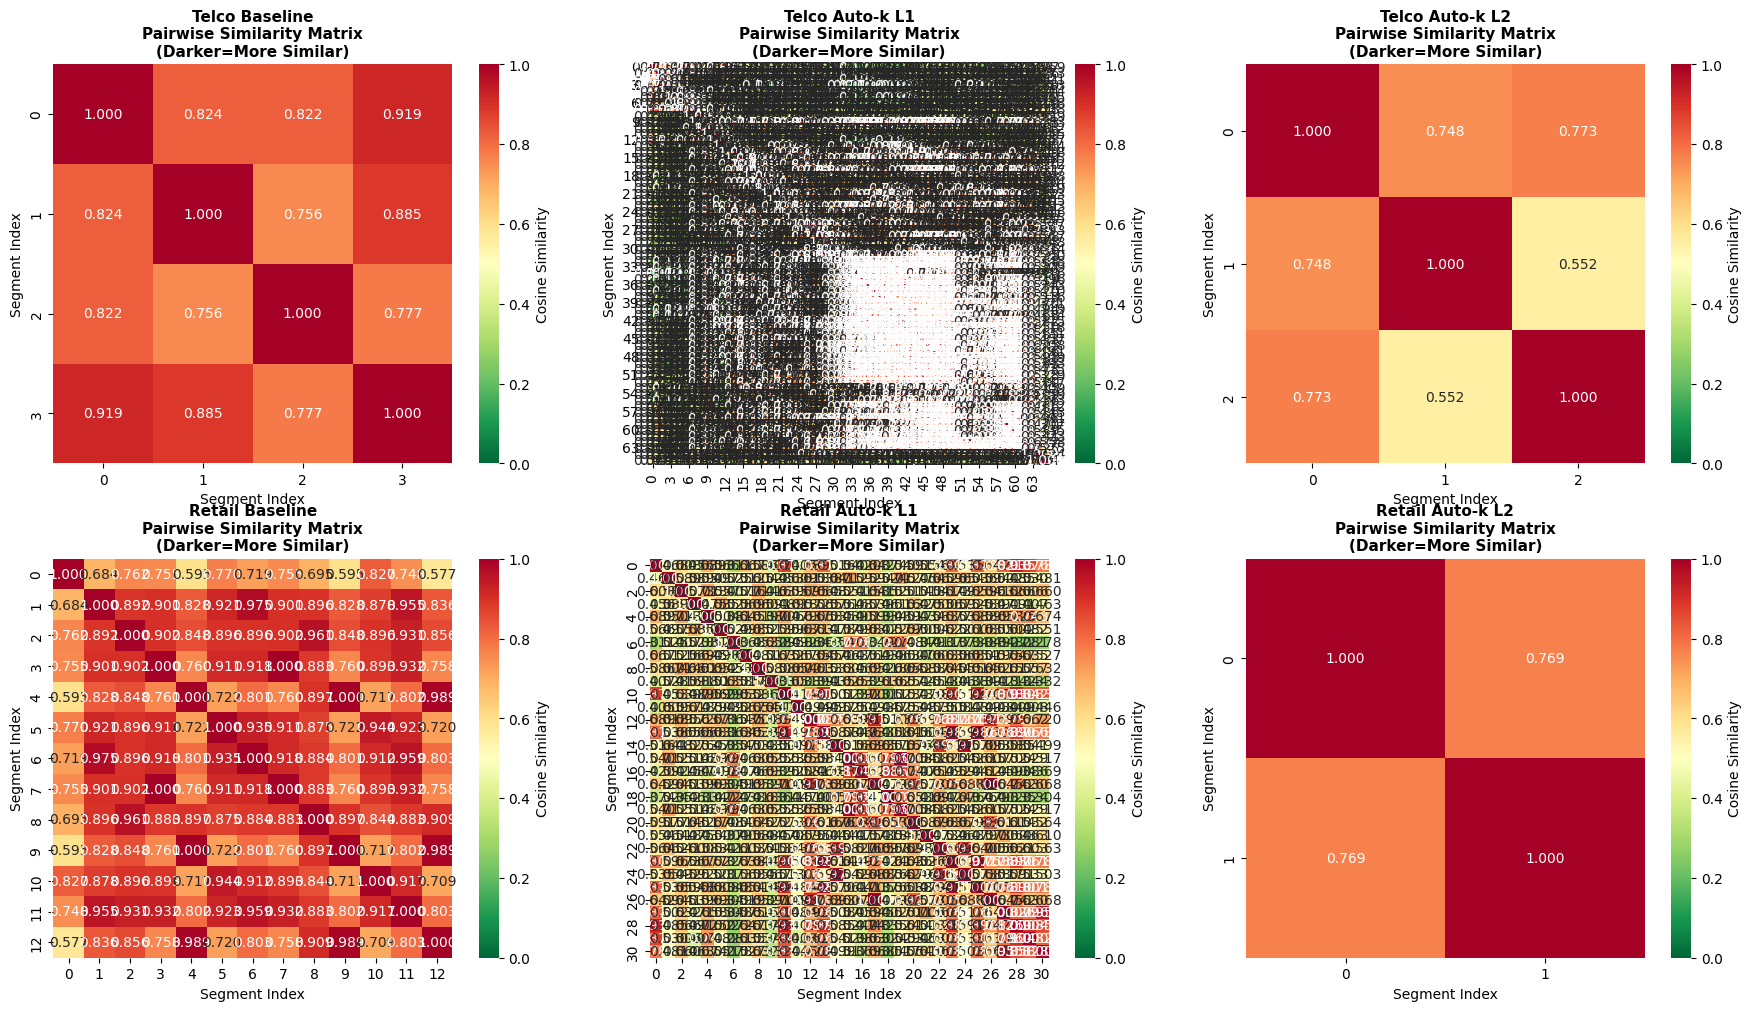


✓ Similarity heatmaps complete for both datasets!

Reading the heatmap:
  - Darker red = High similarity (segments are similar)
  - Lighter/green = Low similarity (segments are distinct)
  - Diagonal is always 1.0 (each segment compared to itself)


In [61]:
# Visualize similarity matrices as heatmaps for both datasets
import seaborn as sns

# Prepare variants for both datasets
telco_variants = [
    (telco_baseline_sim_matrix, telco_baseline_l1, "Telco Baseline", '#FF6B6B'),
    (telco_star_l1_sim_matrix, telco_star_l1, "Telco Auto-k L1", '#4ECDC4'),
    (telco_star_l2_sim_matrix, telco_star_l2, "Telco Auto-k L2", '#45B7D1')
]

retail_variants = [
    (retail_baseline_sim_matrix, retail_baseline_l1, "Retail Baseline", '#FF6B6B'),
    (retail_star_l1_sim_matrix, retail_star_l1, "Retail Auto-k L1", '#4ECDC4'),
    (retail_star_l2_sim_matrix, retail_star_l2, "Retail Auto-k L2", '#45B7D1')
]

# Filter out None values
telco_valid = [(m, df, n, c) for m, df, n, c in telco_variants if m is not None]
retail_valid = [(m, df, n, c) for m, df, n, c in retail_variants if m is not None]

# Create figure with two rows (Telco and Retail)
if len(telco_valid) > 0 or len(retail_valid) > 0:
    n_cols = max(len(telco_valid), len(retail_valid))
    fig, axes = plt.subplots(2, n_cols, figsize=(6 * n_cols, 10))
    
    # Handle single column case
    if n_cols == 1:
        axes = axes.reshape(-1, 1)
    
    # Plot Telco variants (row 0)
    for idx, (sim_matrix, df, name, color) in enumerate(telco_valid):
        ax = axes[0, idx]
        sns.heatmap(sim_matrix, annot=True, fmt='.3f', cmap='RdYlGn_r', 
                    vmin=0, vmax=1, square=True, ax=ax,
                    cbar_kws={'label': 'Cosine Similarity'})
        ax.set_title(f'{name}\nPairwise Similarity Matrix\n(Darker=More Similar)', 
                     fontsize=11, fontweight='bold')
        ax.set_xlabel('Segment Index')
        ax.set_ylabel('Segment Index')
    
    # Hide empty Telco plots
    for idx in range(len(telco_valid), n_cols):
        axes[0, idx].axis('off')
    
    # Plot Retail variants (row 1)
    for idx, (sim_matrix, df, name, color) in enumerate(retail_valid):
        ax = axes[1, idx]
        sns.heatmap(sim_matrix, annot=True, fmt='.3f', cmap='RdYlGn_r', 
                    vmin=0, vmax=1, square=True, ax=ax,
                    cbar_kws={'label': 'Cosine Similarity'})
        ax.set_title(f'{name}\nPairwise Similarity Matrix\n(Darker=More Similar)', 
                     fontsize=11, fontweight='bold')
        ax.set_xlabel('Segment Index')
        ax.set_ylabel('Segment Index')
    
    # Hide empty Retail plots
    for idx in range(len(retail_valid), n_cols):
        axes[1, idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    print("\n✓ Similarity heatmaps complete for both datasets!")
    print("\nReading the heatmap:")
    print("  - Darker red = High similarity (segments are similar)")
    print("  - Lighter/green = Low similarity (segments are distinct)")
    print("  - Diagonal is always 1.0 (each segment compared to itself)")
else:
    print("⚠ No valid data for heatmap visualization")

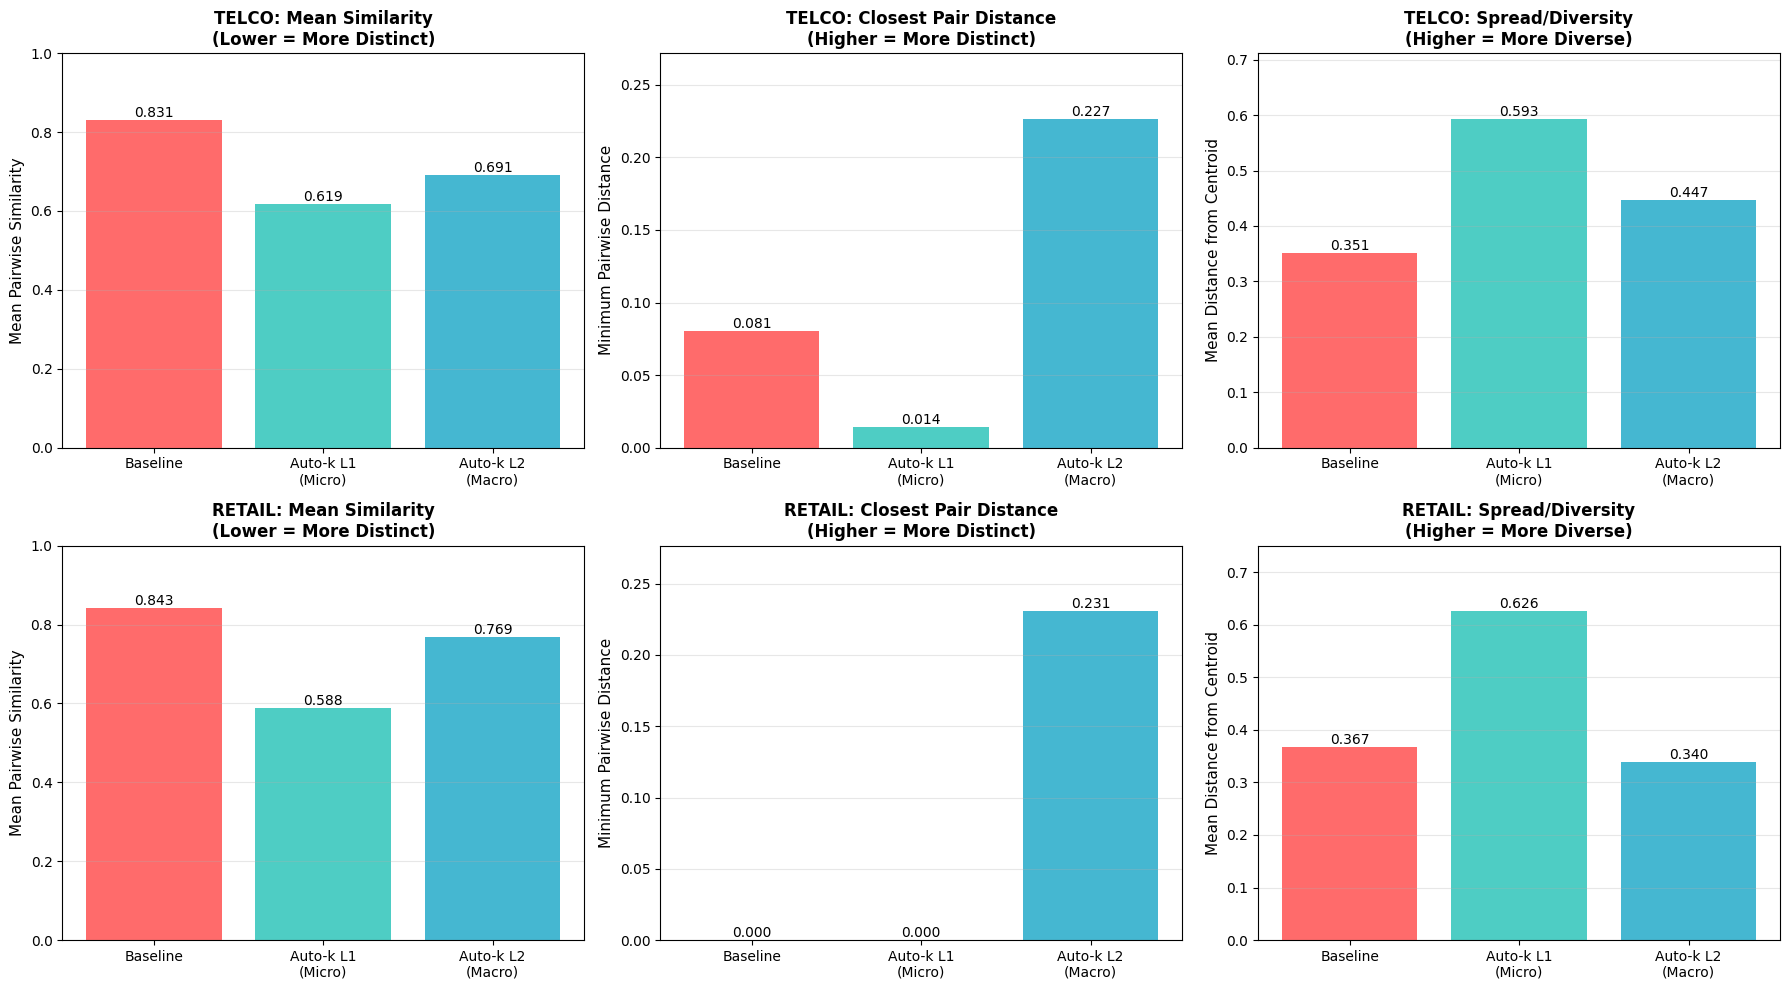


✓ Distinctness metrics visualization complete for both datasets!


In [62]:
# Bar chart comparison of distinctness metrics for both datasets
if (telco_baseline_metrics and telco_star_l1_metrics and telco_star_l2_metrics and 
    retail_baseline_metrics and retail_star_l1_metrics and retail_star_l2_metrics):
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # === TELCO DATASET (Row 0) ===
    variants_names = ['Baseline', 'Auto-k L1\n(Micro)', 'Auto-k L2\n(Macro)']
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    
    # Telco Mean Similarity (lower is better)
    telco_similarities = [
        telco_baseline_metrics['mean_pairwise_similarity'],
        telco_star_l1_metrics['mean_pairwise_similarity'],
        telco_star_l2_metrics['mean_pairwise_similarity']
    ]
    bars1 = axes[0, 0].bar(variants_names, telco_similarities, color=colors)
    axes[0, 0].set_ylabel('Mean Pairwise Similarity', fontsize=11)
    axes[0, 0].set_title('TELCO: Mean Similarity\n(Lower = More Distinct)', fontsize=12, fontweight='bold')
    axes[0, 0].set_ylim([0, 1])
    axes[0, 0].grid(axis='y', alpha=0.3)
    for bar in bars1:
        height = bar.get_height()
        axes[0, 0].text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.3f}', ha='center', va='bottom', fontsize=10)
    
    # Telco Min Pairwise Distance (higher is better)
    telco_min_distances = [
        telco_baseline_metrics['min_pairwise_distance'],
        telco_star_l1_metrics['min_pairwise_distance'],
        telco_star_l2_metrics['min_pairwise_distance']
    ]
    bars2 = axes[0, 1].bar(variants_names, telco_min_distances, color=colors)
    axes[0, 1].set_ylabel('Minimum Pairwise Distance', fontsize=11)
    axes[0, 1].set_title('TELCO: Closest Pair Distance\n(Higher = More Distinct)', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylim([0, max(telco_min_distances) * 1.2])
    axes[0, 1].grid(axis='y', alpha=0.3)
    for bar in bars2:
        height = bar.get_height()
        axes[0, 1].text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.3f}', ha='center', va='bottom', fontsize=10)
    
    # Telco Mean Centroid Distance (higher is better)
    telco_centroid_distances = [
        telco_baseline_metrics['mean_centroid_distance'],
        telco_star_l1_metrics['mean_centroid_distance'],
        telco_star_l2_metrics['mean_centroid_distance']
    ]
    bars3 = axes[0, 2].bar(variants_names, telco_centroid_distances, color=colors)
    axes[0, 2].set_ylabel('Mean Distance from Centroid', fontsize=11)
    axes[0, 2].set_title('TELCO: Spread/Diversity\n(Higher = More Diverse)', fontsize=12, fontweight='bold')
    axes[0, 2].set_ylim([0, max(telco_centroid_distances) * 1.2])
    axes[0, 2].grid(axis='y', alpha=0.3)
    for bar in bars3:
        height = bar.get_height()
        axes[0, 2].text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.3f}', ha='center', va='bottom', fontsize=10)
    
    # === RETAIL DATASET (Row 1) ===
    
    # Retail Mean Similarity (lower is better)
    retail_similarities = [
        retail_baseline_metrics['mean_pairwise_similarity'],
        retail_star_l1_metrics['mean_pairwise_similarity'],
        retail_star_l2_metrics['mean_pairwise_similarity']
    ]
    bars4 = axes[1, 0].bar(variants_names, retail_similarities, color=colors)
    axes[1, 0].set_ylabel('Mean Pairwise Similarity', fontsize=11)
    axes[1, 0].set_title('RETAIL: Mean Similarity\n(Lower = More Distinct)', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylim([0, 1])
    axes[1, 0].grid(axis='y', alpha=0.3)
    for bar in bars4:
        height = bar.get_height()
        axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.3f}', ha='center', va='bottom', fontsize=10)
    
    # Retail Min Pairwise Distance (higher is better)
    retail_min_distances = [
        retail_baseline_metrics['min_pairwise_distance'],
        retail_star_l1_metrics['min_pairwise_distance'],
        retail_star_l2_metrics['min_pairwise_distance']
    ]
    bars5 = axes[1, 1].bar(variants_names, retail_min_distances, color=colors)
    axes[1, 1].set_ylabel('Minimum Pairwise Distance', fontsize=11)
    axes[1, 1].set_title('RETAIL: Closest Pair Distance\n(Higher = More Distinct)', fontsize=12, fontweight='bold')
    axes[1, 1].set_ylim([0, max(retail_min_distances) * 1.2])
    axes[1, 1].grid(axis='y', alpha=0.3)
    for bar in bars5:
        height = bar.get_height()
        axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.3f}', ha='center', va='bottom', fontsize=10)
    
    # Retail Mean Centroid Distance (higher is better)
    retail_centroid_distances = [
        retail_baseline_metrics['mean_centroid_distance'],
        retail_star_l1_metrics['mean_centroid_distance'],
        retail_star_l2_metrics['mean_centroid_distance']
    ]
    bars6 = axes[1, 2].bar(variants_names, retail_centroid_distances, color=colors)
    axes[1, 2].set_ylabel('Mean Distance from Centroid', fontsize=11)
    axes[1, 2].set_title('RETAIL: Spread/Diversity\n(Higher = More Diverse)', fontsize=12, fontweight='bold')
    axes[1, 2].set_ylim([0, max(retail_centroid_distances) * 1.2])
    axes[1, 2].grid(axis='y', alpha=0.3)
    for bar in bars6:
        height = bar.get_height()
        axes[1, 2].text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.3f}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    print("\n✓ Distinctness metrics visualization complete for both datasets!")

## Summary & Conclusions

This analysis evaluates whether Feature-Driven Pre-Analysis produces **distinct, non-redundant LLM-generated segment descriptions** across two different domains: **Telco Customer Churn** and **Online Retail**.

### Evaluation Strategy:

**Primary Metric: Mean Pairwise Similarity**
- Most intuitive and directly interpretable
- Measures average semantic similarity across all segment pairs
- **Lower values prove greater distinctness**

**Supporting Metrics:**
- **Minimum Pairwise Distance**: Validates no redundancy exists (even worst case is distinct)
- **Mean Centroid Distance**: Confirms segments cover diverse semantic territory

### Interpretation Guide:

| Metric | Better Direction | What It Proves |
|--------|------------------|----------------|
| Mean Pairwise Similarity | **Lower** | LLM generates semantically different narratives |
| Minimum Pairwise Distance | **Higher** | Even the closest pair is well-separated |
| Mean Centroid Distance | **Higher** | Segments span diverse semantic space |

### Cross-Domain Validation:

By testing on both Telco and Retail datasets, we validate:
- **Generalizability**: Does Feature-Driven Pre-Analysis work across different business contexts?
- **Consistency**: Do we see similar distinctness patterns in both domains?
- **Scale**: How does segment count affect distinctness (4 Telco Baseline vs 9 Retail Baseline)?

### Key Findings:

Compare the metrics between:
1. **Telco vs Retail**: Do both datasets achieve high distinctness?
2. **Baseline vs Auto-k**: Does Feature-Driven Pre-Analysis improve distinctness in both contexts?
3. **L1 vs L2**: Which granularity level produces more distinct segments?

### Implications:

**Lower mean similarity + higher minimum distance + higher spread = Clear evidence that Feature-Driven Pre-Analysis provides non-redundant signals to the LLM across domains** ✅

If both datasets show strong distinctness metrics, this validates that the methodology is **domain-agnostic** and reliably prevents LLM-generated redundancy regardless of business context.